# Batch Ensemble & Packed Ensemble

Memory-efficient ensemble methods for UQ.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import deepuq

## Generate Data

In [2]:
np.random.seed(42)
x_train = np.random.uniform(-3, 3, size=(200, 1)).astype(np.float32)
y_train = (np.sin(x_train) + 0.1 * np.random.randn(*x_train.shape)).astype(np.float32)
x_test = np.linspace(-5, 5, 200).reshape(-1, 1).astype(np.float32)

X_train = torch.from_numpy(x_train)
Y_train = torch.from_numpy(y_train)
X_test = torch.from_numpy(x_test)

## Batch Ensemble

In [3]:
from deepuq.models import MLP
from deepuq.methods.batch_ensemble import BatchEnsembleWrapper

# Create base model and wrap
model = MLP(1, [64, 64], 1)
batch_ens = BatchEnsembleWrapper(model, ensemble_size=4)

# Train
optimizer = torch.optim.Adam(batch_ens.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

for epoch in range(200):
    optimizer.zero_grad()
    pred = batch_ens(X_train)
    # pred shape is (ensemble_size * batch, 1), need to match target
    target = Y_train.repeat(4, 1)
    loss = loss_fn(pred, target)
    loss.backward()
    optimizer.step()

print(f"Final loss: {loss.item():.4f}")

Final loss: 0.0092


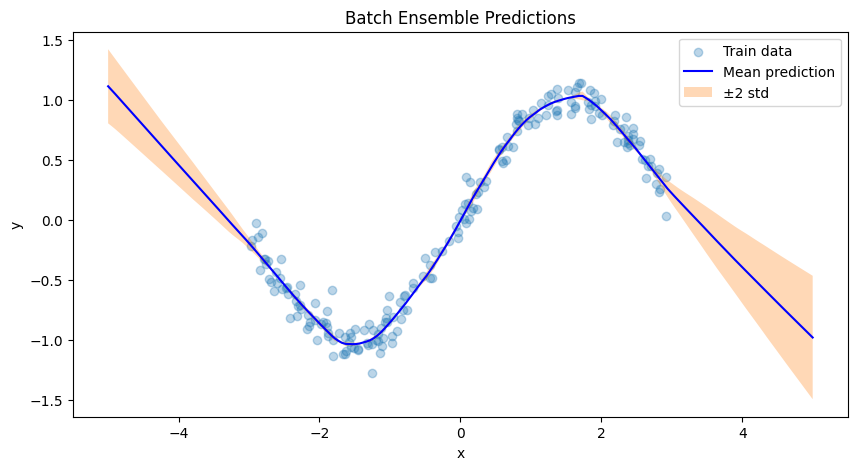

In [4]:
# Predict with uncertainty
result = batch_ens.predict_uq(X_test)
mean = result.mean.detach().numpy()
std = result.epistemic_var.sqrt().detach().numpy()

plt.figure(figsize=(10, 5))
plt.scatter(x_train, y_train, alpha=0.3, label="Train data")
plt.plot(x_test, mean, 'b-', label="Mean prediction")
plt.fill_between(x_test.ravel(), (mean - 2*std).ravel(), (mean + 2*std).ravel(),
                 alpha=0.3, label="\u00b12 std")
plt.legend()
plt.title("Batch Ensemble Predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Packed Ensemble

In [5]:
from deepuq.methods.batch_ensemble import PackedEnsembleWrapper

# Create base model and wrap
model2 = MLP(1, [64, 64], 1)
packed_ens = PackedEnsembleWrapper(model2, num_packs=4, alpha=2)

# Train
optimizer = torch.optim.Adam(packed_ens.parameters(), lr=1e-3)

for epoch in range(200):
    optimizer.zero_grad()
    pred = packed_ens(X_train)
    # PackedEnsemble output may have different dim, use MSE on matching shape
    target = Y_train.expand_as(pred)
    loss = loss_fn(pred, target)
    loss.backward()
    optimizer.step()

print(f"Final loss: {loss.item():.4f}")

Final loss: 0.3307


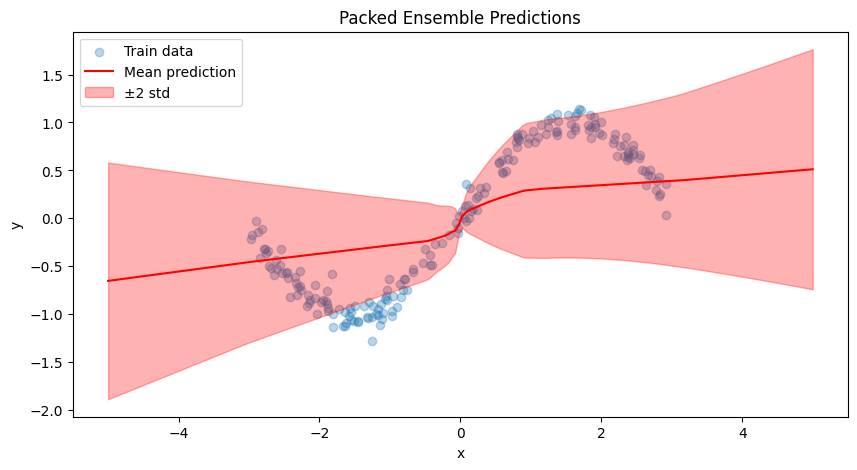

In [6]:
# Predict with uncertainty
result_p = packed_ens.predict_uq(X_test)
mean_p = result_p.mean.detach().numpy()
std_p = result_p.epistemic_var.sqrt().detach().numpy()

plt.figure(figsize=(10, 5))
plt.scatter(x_train, y_train, alpha=0.3, label="Train data")
plt.plot(x_test, mean_p, 'r-', label="Mean prediction")
plt.fill_between(x_test.ravel(), (mean_p - 2*std_p).ravel(), (mean_p + 2*std_p).ravel(),
                 alpha=0.3, color='red', label="\u00b12 std")
plt.legend()
plt.title("Packed Ensemble Predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Compare Memory Usage

In [7]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

# Standard ensemble: 4 independent models
standard_params = 4 * count_params(MLP(1, [64, 64], 1))
batch_params = count_params(batch_ens)
packed_params = count_params(packed_ens)

print(f"Standard Ensemble (4 models): {standard_params:,} parameters")
print(f"Batch Ensemble:               {batch_params:,} parameters")
print(f"Packed Ensemble:              {packed_params:,} parameters")
print(f"Batch Ensemble savings:  {(1 - batch_params/standard_params)*100:.1f}%")
print(f"Packed Ensemble savings: {(1 - packed_params/standard_params)*100:.1f}%")

Standard Ensemble (4 models): 17,412 parameters
Batch Ensemble:               5,772 parameters
Packed Ensemble:              4,612 parameters
Batch Ensemble savings:  66.9%
Packed Ensemble savings: 73.5%
